# Real Estate Taxonomy Data Exploration

This notebook explores the structured real estate terminology and the dataset extracted from `rets_property.sql`.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

## 1. Analyze Sample Listings

Total Sample Listings: 1000
Average Remark Length: 406.99 characters


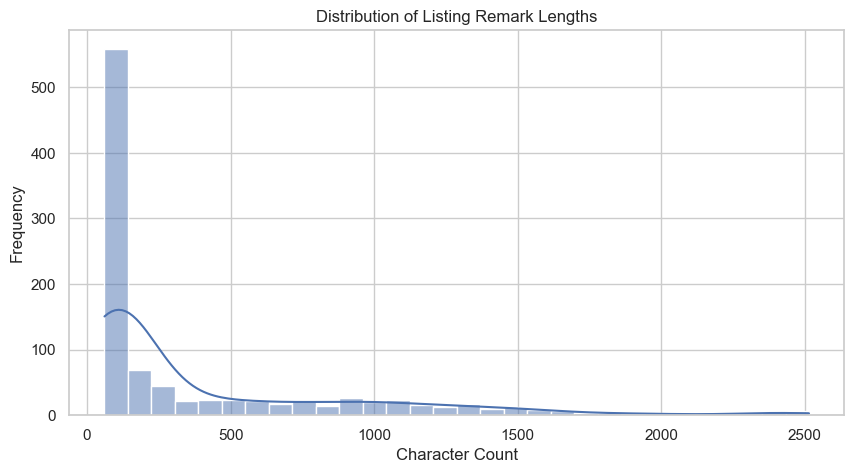

In [2]:
df = pd.read_csv('../data/processed/sample_listing.csv')
df['remark_length'] = df['remarks'].apply(lambda x: len(str(x)))

print(f"Total Sample Listings: {len(df)}")
print(f"Average Remark Length: {df['remark_length'].mean():.2f} characters")

plt.figure(figsize=(10, 5))
sns.histplot(df['remark_length'], bins=30, kde=True)
plt.title('Distribution of Listing Remark Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

## 2. Analyze the Taxonomy

C:\Users\desai\AppData\Local\Temp\ipykernel_35360\3484433497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')


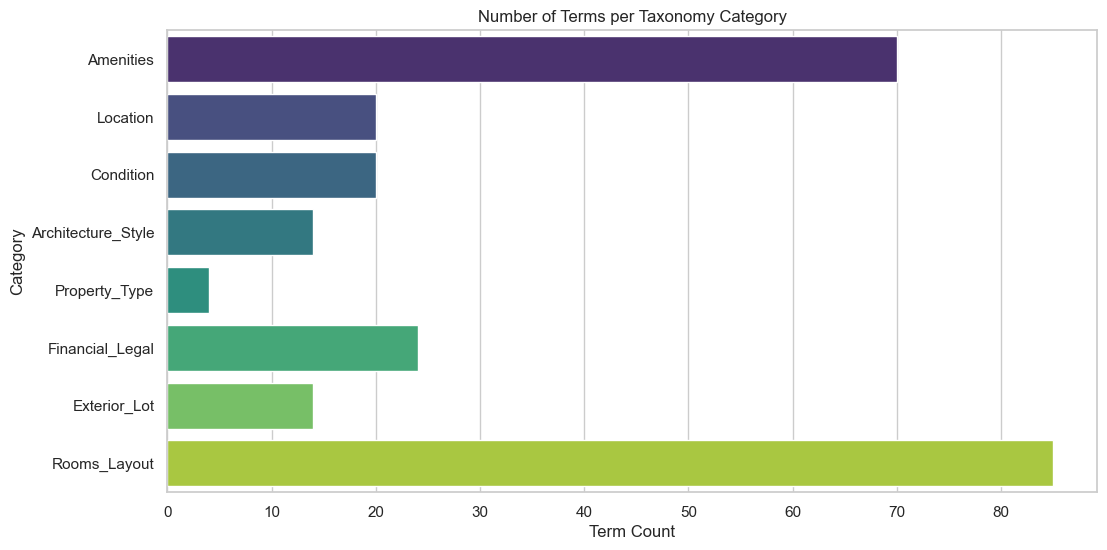

Total terms categorized: 251


In [3]:
with open('../data/processed/taxonomy.json', 'r') as f:
    taxonomy = json.load(f)

from collections import Counter
category_counts = dict(Counter(item['category'] for item in taxonomy.get('terms', [])))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')
plt.title('Number of Terms per Taxonomy Category')
plt.xlabel('Term Count')
plt.ylabel('Category')
plt.show()

total_terms = sum(category_counts.values())
print(f"Total terms categorized: {total_terms}")

## 3. Text Cleaning and Data Profiling

In Week 2, we built a `TextCleaner` class to normalize text involving Unicode decoding errors, HTML remnants, price abbreviations, measurements, and real estate jargon.

In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
from scripts.text_cleaning import TextCleaner

cleaner = TextCleaner()

# 1. Profile Before Cleaning
profile = cleaner.profile_column(df, 'remarks')
print("=== Data Profiling Report (Before Cleaning) ===")
print(f"Null Rate: {profile.get('null_rate', 0):.2%}")
print(f"Average Remark Length: {profile.get('avg_length', 0):.1f} characters")
print(f"Price Mentions (contains $x): {profile.get('price_mentions', 0)}")
print(f"HTML Tags Found In: {profile.get('has_html', 0)} listings")
print("Common Abbreviations Found:")
for abbrev, count in profile.get('common_abbreviations', {}).items():
    print(f"  - {abbrev}: {count}")
print("\nCommon Terms:")
for term, count in profile.get('common_terms', {}).items():
    print(f"  - {term}: {count}")


=== Data Profiling Report (Before Cleaning) ===
Null Rate: 0.00%
Average Remark Length: 407.0 characters
Price Mentions (contains $x): 21
HTML Tags Found In: 0 listings
Common Abbreviations Found:
  - sqft: 12
  - w/: 8
  - ba: 6
  - ac: 6
  - dr: 5
  - rm: 3
  - ss: 2
  - br: 1

Common Terms:
  - null,: 1167
  - with: 1103
  - this: 667
  - home: 545
  - living: 370
  - offers: 241
  - kitchen: 220
  - room: 219
  - private: 202
  - features: 199
  - that: 198
  - your: 191
  - from: 191
  - spacious: 183
  - large: 160
  - located: 152
  - perfect: 147
  - property: 135
  - space: 133
  - modern: 129


In [5]:
# 2. Apply Text Cleaner
df['cleaned_remarks'] = df['remarks'].apply(lambda x: cleaner.clean_text(str(x)) if pd.notnull(x) else "")

# Show improvements
changed_df = df[df['remarks'].astype(str) != df['cleaned_remarks']]
print(f"\nTotal cleaned remarks out of {len(df)} listings: {len(changed_df)}\n")
sample_df = changed_df.sample(min(3, len(changed_df)), random_state=42)
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    print(f"Example {i}:")
    print(f"BEFORE: {str(row['remarks'])[:200]}...")
    print(f"AFTER:  {str(row['cleaned_remarks'])[:200]}...\n")



Total cleaned remarks out of 1000 listings: 466

Example 1:
BEFORE: Nestled on a peaceful cul-de-sac in the sought-after Harbor Ridge community of Rancho San Clemente, this gorgeous 4-bedroom, 3-bathroom home offers approximately 2,500 sq. ft. of coastal living space ...
AFTER:  Nestled on a peaceful cul-de-sac in the sought-after Harbor Ridge community of Rancho San Clemente, this gorgeous 4-bedroom, 3-bathroom home offers approximately 2500 square feet of coastal living spa...

Example 2:
BEFORE: Welcome to a home designed for real life. Built in 2022, this home offers nearly 2,900 sqft of thoughtfully designed living space with a rare multi-gen layout that provides flexibility, privacy, and l...
AFTER:  Welcome to a home designed for real life. Built in 2022, this home offers nearly 2900 square feet of thoughtfully designed living space with a rare multi-gen layout that provides flexibility, privacy,...

Example 3:
BEFORE: , 0, 0, 0, NULL, NULL, 0, 0, 1, 1, 1, 0, 0, 1, 183, 0, 1, N

### Visualizing Profiling Information
Let's visualize the most common abbreviations found in our remarks before cleaning.

C:\Users\desai\AppData\Local\Temp\ipykernel_35360\2378821766.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(abbrevs.values()), y=list(abbrevs.keys()), palette='viridis')


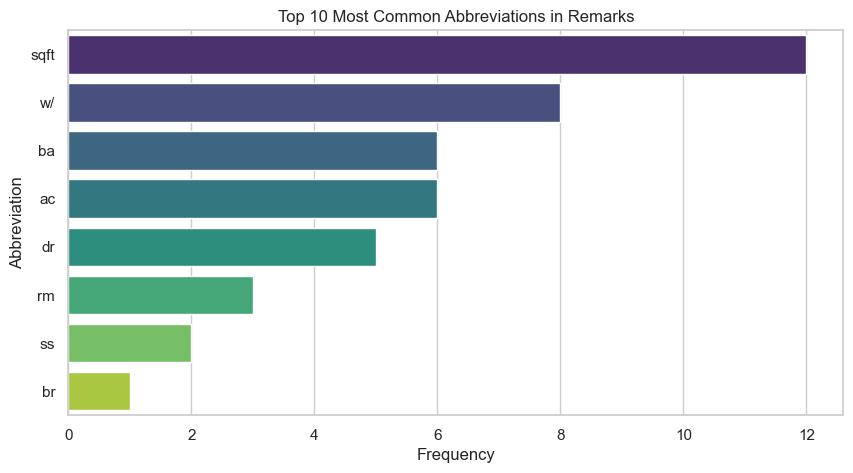

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get common abbreviations from our profile
abbrevs = profile.get('common_abbreviations', {})

if abbrevs:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(abbrevs.values()), y=list(abbrevs.keys()), palette='viridis')
    plt.title('Top 10 Most Common Abbreviations in Remarks')
    plt.xlabel('Frequency')
    plt.ylabel('Abbreviation')
    plt.show()
else:
    print('No common abbreviations found to plot.')
